# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading

In [2]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')


Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [3]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    
    padded = start_symbol*(n-1) + text + end_symbol*n
    
    for i in range(len(padded) - n + 1):
        yield padded[i:i+n]

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [4]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if(count>=rare_threshold):
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare+=1

    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<?, ?it/s]


Building mapping...


100%|██████████| 15/15 [00:00<?, ?it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [5]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)
            
            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev in prev_indices[-window_size:]:
                co_matrix[prev, idx] = co_matrix.get((prev, idx), 0) + 1
                co_matrix[idx, prev] = co_matrix.get((idx, prev), 0) + 1
            
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i] > 0:
            co_matrix[i, j] = co_matrix[i, j] / row_sums[i]
    
    return co_matrix

In [6]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 54391.62it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 3220472.64it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [03:54<00:00, 154.83it/s]


Normalizing...


100%|██████████| 2542234/2542234 [01:05<00:00, 38841.64it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [7]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [9]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = url.ljust(padded_len, pad_symbol)
        
        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [10]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [16]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = torch.nn.Embedding.from_pretrained( torch.tensor(embedding_weights, dtype=torch.float), freeze=True)
        
        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = torch.nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = torch.nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = torch.nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool1 = torch.nn.MaxPool1d(2)
        self.pool2 = torch.nn.MaxPool1d(5)
        self.pool3 = torch.nn.MaxPool1d(5)

        
        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = torch.nn.Linear(160, 16)
        self.fc2 = torch.nn.Linear(16, 1)
    
    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x).permute(0, 2, 1)  # (B, E, L)
        x = self.pool1(torch.relu(self.conv1(x)))  
        x = self.pool2(torch.relu(self.conv2(x)))  
        x = self.pool3(torch.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = torch.sigmoid(x).squeeze(1)
        return x

In [17]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [26]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        lossitem = loss.item()
        size = len(y)
        total_loss = lossitem*size
        
        prediction = (out > 0.5)

        correct += (prediction == y).sum().item()
        total += size

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [19]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.6685, Val Acc=0.8609
Epoch 2: Train Acc=0.8731, Val Acc=0.8775
Epoch 3: Train Acc=0.8949, Val Acc=0.9057
Epoch 4: Train Acc=0.9008, Val Acc=0.8937
Epoch 5: Train Acc=0.9075, Val Acc=0.9107
Epoch 6: Train Acc=0.9142, Val Acc=0.9105
Epoch 7: Train Acc=0.9191, Val Acc=0.9126
Epoch 8: Train Acc=0.9198, Val Acc=0.9238
Epoch 9: Train Acc=0.9248, Val Acc=0.9273
Epoch 10: Train Acc=0.9279, Val Acc=0.9293


## 6. Evaluation

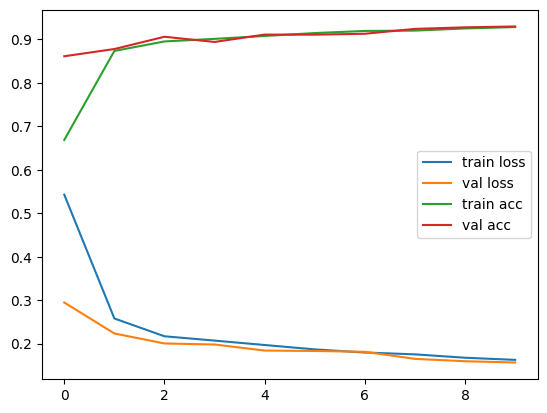

In [25]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.plot(history['acc'], label='train acc')
plt.plot(history['val_acc'], label='val acc')

plt.legend()
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report


test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        output = model(x)
        predict = (output > 0.5).float()

        y_cpu = y.cpu()
        predict_cpu = predict.cpu()

        y_numpy =  y_cpu.numpy()
        predict_numpy = predict_cpu.numpy() 
        
        y_true.extend(y_numpy)
        y_pred.extend(predict_numpy)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[6860  283]
 [ 598 4369]]
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      7143
         1.0       0.94      0.88      0.91      4967

    accuracy                           0.93     12110
   macro avg       0.93      0.92      0.92     12110
weighted avg       0.93      0.93      0.93     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

The model acieves an f1-score of 0.91. This shows the model performs well on the test set. The confusion matrix shows most samples are classified correctly in the upper left and lower right with a few incorrect. The model overall does better for benign urls with an f1-score of 0.94. This means that it correctly classifies benign urls more of the time than malicious ones. However overall the model is still very accurate. 

Yes lower loss indicates higher accuracy. As we see in the graph above the training loss decrease directly corresponded with an accuracy increase. This makes sense as loss is a measure of how wrong the models prediction is compared to the label. So as the measure of how wrong the models prediction is decreases the accuracy of the model in turn increases. 



**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

No a large window size is not good. A large window size compares n-grams that are far apart in the url. Most of the time in this case they are not related. Smaller windows though capture valuable relationships between n-grams. Other compression methods include PCA and autoencoders. 


## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`